In [1]:
import phoebe
import lightkurve as lk

import sys
sys.path.insert(1, '../scripts')
import phoebe_to_eBEER

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from astropy import units as u

from scipy.linalg import lstsq
from scipy.optimize import curve_fit


PHOEBE: passband "Bolometric:900-40000" has a newer version available.  Run phoebe.list_passband_online_history("Bolometric:900-40000") to get a list of available changes and phoebe.update_passband("Bolometric:900-40000") or phoebe.update_all_passbands() to update.
PHOEBE: passband "Johnson:V" has a newer version available.  Run phoebe.list_passband_online_history("Johnson:V") to get a list of available changes and phoebe.update_passband("Johnson:V") or phoebe.update_all_passbands() to update.


# Testing Utils

In [2]:
def get_phoebe_binary(Porb= 1, t0= -0.25, M1= 0.9988131358058301, M2= 0.9988131358058301,
                     R1= 1, R2= 1, T1= 6000, T2= 6000, incl= 90, per0= 0, ecc= 0,
                     u1= 0.5, u2= 0.5, tau1= 0.32, tau2= 0.32, metallicity= None):
    """Configure a PHOEBE binary with input parameters"""
    # ??? Assumes Prot of stars = Porb of system (default PHOEBE behavior)
    # Init with PHOEBE system defaults

    binary = phoebe.default_binary()

    binary['primary']['teff'].set_value(T1 * u.K)
    binary['secondary']['teff'].set_value(T2 * u.K)

    orbit = binary['orbit']
    orbit['period'].set_value(Porb * u.day)

    orbit['incl'].set_value(incl * u.deg)

    orbit['ecc'].set_value(ecc)
    orbit['per0'].set_value(per0 * u.deg)

    binary.flip_constraint('mass@primary', solve_for='sma')
    binary.flip_constraint('mass@secondary', solve_for='q')
    binary['primary']['mass'].set_value(M1 * u.M_sun)
    binary['secondary']['mass'].set_value(M2 * u.M_sun)

    binary['primary']['requiv'].set_value(R1 * u.R_sun)
    binary['secondary']['requiv'].set_value(R2 * u.R_sun)

    binary.flip_constraint('t0_perpass', solve_for= 't0_supconj')
    orbit['t0_perpass'].set_value(t0 * u.day)
    
    for component in ['primary', 'secondary']:
        binary[component]['ld_mode_bol'].set_value('manual')
        binary[component]['ld_func_bol'].set_value('linear')
    
    binary['primary']['ld_coeffs_bol'].set_value(u1)
    binary['secondary']['ld_coeffs_bol'].set_value(u2)
    binary['primary']['gravb_bol'].set_value(tau1)
    binary['secondary']['gravb_bol'].set_value(tau2)

    if (metallicity is not None):
        binary['primary@abun'] = metallicity
        binary['secondary@abun'] = metallicity

    return binary

In [3]:
def prefit_eval(binary, times, flux_to_fit):
    Porb = binary['orbit@period'].get_value(u.day)
    t0_perpass = binary['orbit@t0_perpass'].get_value(u.day)
    flux = phoebe_to_eBEER.get_eBEER_lc(binary, times, 0,0,0,0)
    phase = (times) % Porb

    plt.figure(figsize=(16,5), label= 'Gauge initial guess for time shift')
    plt.subplot(121)
    plt.plot(times, flux_to_fit, 'b.', markersize= 1, label= 'Flux to fit')
    plt.plot(times, flux, 'r', label= 'eBEER w/o beaming or reflection')
    plt.legend()

    plt.subplot(122)
    plt.plot(phase, flux_to_fit, 'b.', markersize= 1, label= 'Flux to fit')
    plt.plot(phase, flux, 'r', label= 'eBEER w/o beaming or reflection')
    plt.legend()

# Engel et al. 2020 System Params

In [4]:
systems = ('KIC6292925', 'KIC5200778', 'KIC4931390')

KIC6292925 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [13.6126, 13.6122],
    "t0_perpass": [874.04, 875.977],
    "M1": [1.9, 1.89],
    "M2": [0.50, 0.50],
    "R1": [1.8, 1.80],
    "R2": [1.3, 1.10],
    "T1": [8300, 8400],
    "T2": [6000, 7000],
    "incl": [71, 72],
    "per0": [157, 153],
    "ecc": [0.232, 0.2491],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [0.087, 0.087],
    "u1": [0.622, 0.606], # ??? Had to use Kurucz ATLAS9 Model as the Phoenix ACES model (better for Kepler Bandpass) doesnt cover Teff range
    "u2": [0.741, 0.616],
}

KIC5200778 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [16.357, 16.3536],
    "t0_perpass": [806.6, 804.2],
    "M1": [1.2, 1.20],
    "M2": [0.40, 0.37],
    "R1": [2.4, 2.30],
    "R2": [0.14, 0.47],
    "T1": [6000, 6500],
    "T2": [4000, 3500],
    "incl": [23, 24],
    "per0": [-1, 2],
    "ecc": [0.35, 0.26],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [None,None], # ??? Not available in MAST table so defaulting to 0
    "u1": [0.741, 0.687],
    "u2": [0.577, 0.774],
}

KIC4931390 = {
    "Fitted Model": ['eBEER', 'PHOEBE'],
    "Porb": [7.6064, 7.6080],
    "t0_perpass": [798.44, 794.78],
    "M1": [1.20, 1.10],
    "M2": [0.10, 0.13],
    "R1": [1.48, 1.42],
    "R2": [0.7, 0.66],
    "T1": [6500, 6620],
    "T2": [5500, 6500],
    "incl": [50, 35],
    "per0": [158, 160],
    "ecc": [0.08, 0.040],
    # Following found in MAST data and through ExoCTK calculations
    "metallicity": [-0.313, -0.313],
    "u1": [0.695, 0.693],
    "u2": [0.736, 0.695],
}

dfs = (KIC6292925, KIC5200778, KIC4931390)

def grab_fit_params(df, idx):
    cur_fit_params = df.loc[idx]
    fit_type = cur_fit_params['Fitted Model']
    Porb = cur_fit_params['Porb']
    t0_perpass = cur_fit_params['t0_perpass']
    M1 = cur_fit_params['M1']
    M2 = cur_fit_params['M2']
    R1 = cur_fit_params['R1']
    R2 = cur_fit_params['R2']
    T1 = cur_fit_params['T1']
    T2 = cur_fit_params['T2']
    incl = cur_fit_params['incl']
    per0 = cur_fit_params['per0']
    ecc = cur_fit_params['ecc']
    u1 = cur_fit_params['u1']
    u2 = cur_fit_params['u2']
    abun = cur_fit_params['metallicity']
    pb = get_phoebe_binary(Porb, t0_perpass, M1, M2, R1, R2, T1, T2, incl, per0, ecc, u1, u2, metallicity= abun)
    return fit_type, pb

# Select System

In [7]:
i = 1
target_name = systems[i]
df = pd.DataFrame(dfs[i])
fit_type_P, phoebe_binary_P = grab_fit_params(df, 1)
Pp = phoebe_to_eBEER.eBEERParams(phoebe_binary_P, times= 0) # Kepler Fit Params Wrapper
print(target_name, fit_type_P)

KIC5200778 PHOEBE


# Setup PHOEBE Binary and Run LC Dataset

In [8]:
time_P = np.linspace(Pp.t0, Pp.t0 + 1.5*Pp.Porb,151)

phoebe_binary_P.add_dataset('lc', times= time_P, dataset='lc01', overwrite=True)
phoebe_binary_P.set_value_all('ntriangles', 10000)
# phoebe_binary_P.set_value_all('irrad_frac_refl_bol', 0.9)
phoebe_binary_P['eclipse_method'] = 'only_horizon'
phoebe_binary_P['passband'] = 'Kepler:mean'
phoebe_binary_P.set_value_all('atm', 'phoenix')
phoebe_binary_P.run_compute()

100%|██████████| 151/151 [04:36<00:00,  1.83s/it]


<ParameterSet: 3 parameters | qualifiers: comments, fluxes, times>

In [9]:
_, phoebe_binary_P2 = grab_fit_params(df, 1)
phoebe_binary_P2.add_dataset('lc', times=0, label= 'lc01')
phoebe_binary_P2.set_value_all('ntriangles', 10000)
phoebe_binary_P2['eclipse_method'] = 'only_horizon'
phoebe_binary_P2['passband'] = 'Kepler:mean'
phoebe_binary_P2.set_value_all('atm', 'phoenix')
phoebe_binary_P2.set_value('irrad_method', 'none')
phoebe_binary_P2.set_value_all('distortion_method', value='sphere')
phoebe_binary_P2.run_compute()

100%|██████████| 1/1 [00:00<00:00,  6.34it/s]


<ParameterSet: 3 parameters | qualifiers: comments, fluxes, times>

In [10]:
flux = phoebe_binary_P[f'fluxes@lc01@latest@model'].value
ref_flux = phoebe_binary_P2['fluxes@lc01@latest@model'].value
relative_flux_ = (flux - ref_flux)/ref_flux * 1e6

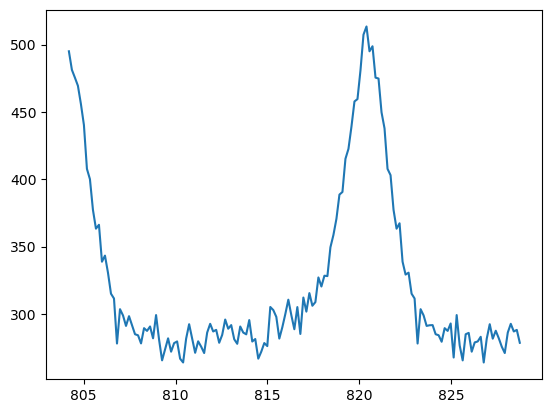

In [11]:
plt.plot(time_P, relative_flux_)

# Run Fit

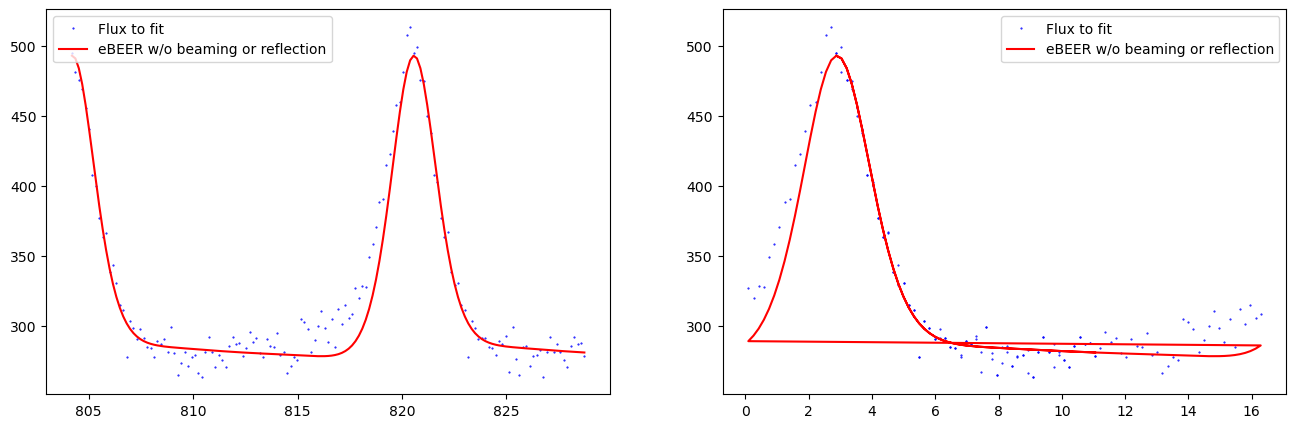

In [12]:
prefit_eval(phoebe_binary_P, time_P, relative_flux_)

In [21]:
def fit_scaling_PHOEBE(time_shift, arefl1, arefl2):
    scaled = np.zeros(3)
    scaled[0] = time_shift * Pp.Porb
    scaled[1] = arefl1 * 7
    scaled[2] = arefl2 * 7
    return scaled

def fit_eBEER_PHOEBE(t, time_shift, arefl1, arefl2):
   
  scaled = fit_scaling_PHOEBE(time_shift, arefl1, arefl2)

  flux = phoebe_to_eBEER.get_eBEER_lc(phoebe_binary_P, (t + scaled[0]) % Pp.Porb, 0, 0, scaled[1], scaled[2])
  
  return flux

In [22]:
popt_P, pcov_P = curve_fit(fit_eBEER_PHOEBE, time_P, relative_flux_, p0= ((0)/Pp.Porb, 0.5, 0.5), bounds= ([0, 0, 0], [1, 1, 1]))
print(popt_P)
print(np.sqrt(np.diag(pcov_P))*np.array((Pp.Porb, 7, 7)))

[7.74600803e-03 7.62758718e-03 3.41948615e-18]
[0.02655009 0.00984688 0.10616804]


In [24]:
fit_params_P = ('Time Shift', 'Alpha Reflective 1', 'Alpha Reflective 2')
rescaled_P = fit_scaling_PHOEBE(popt_P[0], popt_P[1], popt_P[2])
for name,value in zip(fit_params_P, rescaled_P):
    print(name+':', value)

Time Shift: 0.12667511692865704
Alpha Reflective 1: 0.05339311024672956
Alpha Reflective 2: 2.3936403079732703e-17


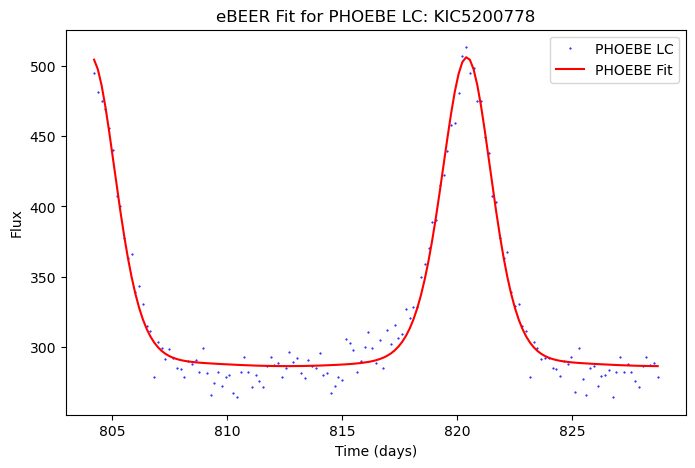

In [25]:
fit_flux_P = fit_eBEER_PHOEBE(time_P, popt_P[0], popt_P[1], popt_P[2])

plt.figure(figsize=(8, 5))
plt.plot(time_P, relative_flux_, 'b.', markersize=1, label= 'PHOEBE LC')
plt.plot(time_P, fit_flux_P, 'r', markersize=1, label= 'PHOEBE Fit')
plt.title(f'eBEER Fit for PHOEBE LC: {target_name}')
plt.xlabel('Time (days)')
plt.ylabel('Flux')
plt.legend()

In [34]:
dif = np.abs(fit_flux_P - relative_flux_)
MSD = np.sqrt(np.mean(dif**2))

print(f'Mean Diff: {np.mean(dif)} ppm   STD: {np.std(dif)} ppm')
print(f'MSD: {MSD} ppm')

Mean Diff: 7.9199756116720526 ppm   STD: 6.2198216409395055 ppm
MSD: 10.07036220473621 ppm
